In [4]:
# Assignment 4 - Demonstrate applying QAOA
import numpy as np
import rustworkx as rx
from rustworkx.visualization import mpl_draw
import matplotlib.pyplot as plt

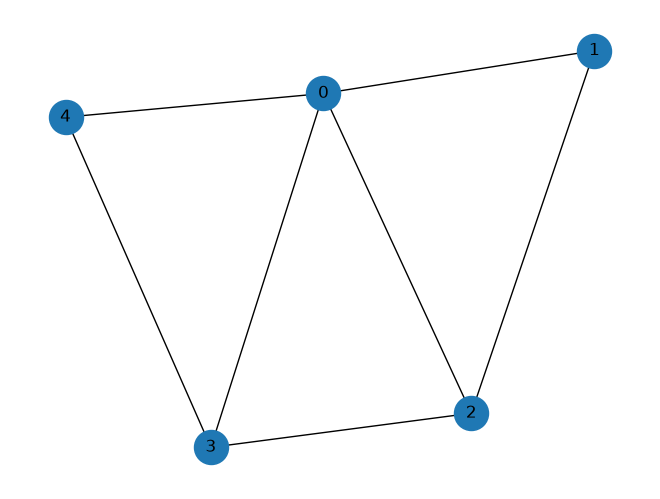

In [254]:
# New graph I made designed for 5 qubits
n = 5
graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n, 1))

edge_list = [
    (0, 1, 1.0),
    (1, 2, 1.0),
    (2, 0, 1.0),
    (3, 4, 1.0),
    (4, 0, 1.0),
    (3, 0, 1.0),
    (2, 3, 1.0)
]
graph.add_edges_from(edge_list)
mpl_draw(graph, node_size=600, with_labels=True)

In [164]:
# This part is HOW the cost function hamiltonian is produced
from qiskit.quantum_info import SparsePauliOp

def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, float]]:
    """Convert the graph to Pauli list."""
    pauli_list = []
    for edge in list(graph.edge_list()):
        weight = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("ZZ", [edge[0], edge[1]], weight))
    return pauli_list

max_cut_paulis = build_max_cut_paulis(graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, n)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIZZ', 'IIZZI', 'IIZIZ', 'ZZIII', 'ZIIIZ', 'IZIIZ', 'IZZII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


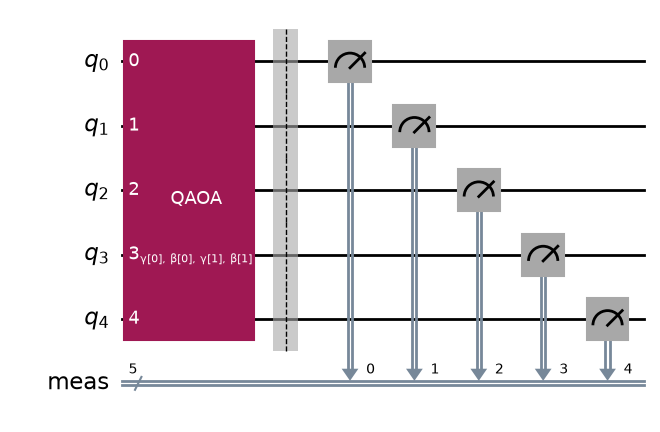

In [165]:
from qiskit.circuit.library import QAOAAnsatz

circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
circuit.measure_all()

circuit.draw('mpl')

In [166]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Load the default service and find a suitable backend
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=127
)
print("Selected backend:", backend)

Selected backend: <IBMBackend('ibm_marrakesh')>




In [222]:
# Transpile the circuit for the selected backend
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
candidate_circuit = pm.run(circuit)

# Visualize the transpiled circuit
candidate_circuit.draw('mpl', fold=False, idle_wires=False)

In [223]:
import numpy as np

initial_gamma = np.pi
initial_beta = np.pi / 2

# For reps=2 (2 layers), we need 2 gammas and 2 betas
init_params = [initial_beta, initial_beta, initial_gamma, initial_gamma]

In [224]:
objective_func_vals = []  # Global variable for tracking optimizer progress

def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    # Map observable to physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])
    
    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost

In [225]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Estimator, Session
from scipy.optimize import minimize
import matplotlib.pyplot as plt

simulator = AerSimulator()

with Session(backend=simulator) as session:
    # For qiskit-ibm-runtime >=0.24.0 use mode=, otherwise use session=
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 1000

    # Error mitigation configuration
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    # Run optimizer
    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit, cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2,
    )
    print(result)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -1.9830169830169833
       x: [ 4.107e+00 -1.291e+00  1.728e+00  1.193e+00]
    nfev: 31
   maxcv: 0.0


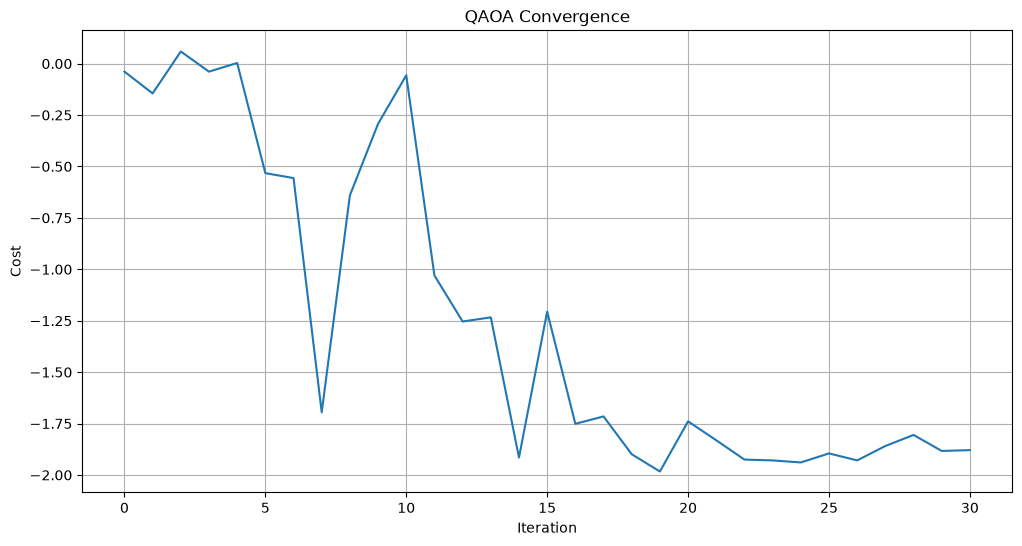

In [226]:
# Convergence graph
plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("QAOA Convergence")
plt.grid(True)
plt.show()

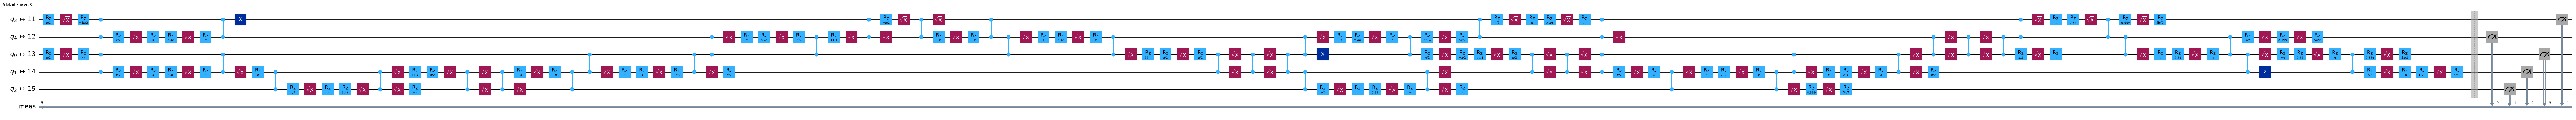

In [227]:
# From here I start referencing IBM docs for Qiskit
optimized_circuit = candidate_circuit.assign_parameters(result.x)
optimized_circuit.draw("mpl", fold=False, idle_wires=False)

In [241]:
# Run Sampler simulation
from qiskit_ibm_runtime import Sampler

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=simulator)
sampler.options.default_shots = 10000

pub = (optimized_circuit,)
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
print(final_distribution_int)

{28: 0.0361, 5: 0.1123, 24: 0.0163, 3: 0.0358, 10: 0.0311, 11: 0.0308, 7: 0.0172, 19: 0.0286, 26: 0.1174, 22: 0.1071, 14: 0.0374, 18: 0.0386, 30: 0.0295, 13: 0.0385, 12: 0.0275, 17: 0.0395, 1: 0.0228, 6: 0.0179, 20: 0.0334, 21: 0.0325, 9: 0.1158, 25: 0.0166, 4: 0.0002, 23: 0.0004, 31: 0.0069, 15: 0.0008, 16: 0.0013, 0: 0.0059, 2: 0.0009, 27: 0.0004, 29: 0.0004, 8: 0.0001}


In [242]:
# Auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]


keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(graph))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [0, 1, 0, 1, 1]


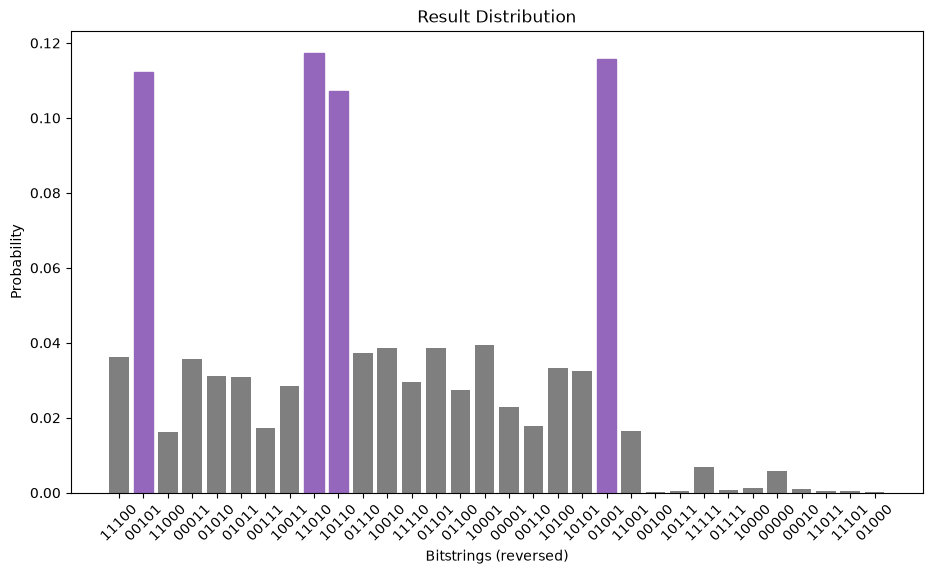

In [244]:
# Graph bitstrings to view most frequent bitstrings in result distribution
plt.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p[0])].set_color("tab:purple")
plt.show()

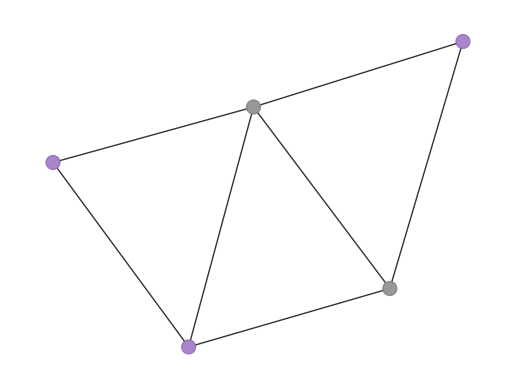

In [249]:
# Auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, _default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(
        G, node_color=colors, node_size=100, alpha=0.8, pos=pos
    )


plot_result(graph, most_likely_bitstring)

In [252]:
# Determine value of the cut
from typing import Sequence

def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(
        list(graph.nodes())
    ), "The length of x must coincide with the number of nodes in the graph."
    return sum(
        x[u] * (1 - x[v]) + x[v] * (1 - x[u])
        for u, v in list(graph.edge_list())
    )

cut_value = evaluate_sample(most_likely_bitstring, graph)
print("The value of the cut is:", cut_value)

The value of the cut is: 5


In [253]:
# Bruteforce solve max cut to check vs. our QAOA algorithm
# Classical baseline: enumerate all 2**n_small bitstrings and take the best cut.
def brute_force_max_cut(graph: rx.PyGraph) -> tuple[int, list[int]]:
    n = len(list(graph.nodes()))
    best_cut = -1
    best_x: list[int] = []
    for i in range(2**n):
        x = [(i >> k) & 1 for k in range(n)]
        cut = evaluate_sample(x, graph)
        if cut > best_cut:
            best_cut = int(cut)
            best_x = x
    return best_cut, best_x


classical_best, classical_x = brute_force_max_cut(graph)
print(f"Classical optimum (brute force): {classical_best}")
print(f"QAOA cut value:                  {cut_value}")

Classical optimum (brute force): 5
QAOA cut value:                  5
